<a href="https://colab.research.google.com/github/SKTan03/ShuKaiTan-Portfolio/blob/main/Student_Exam_Performance_Analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Student Exam Performance — Data Analysis
**Dataset:** 10,000 students | 23 features | Demographics, study habits, and exam scores


## 1. Setup & Data Loading

In [1]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style config
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})



In [8]:
from google.colab import files
uploaded = files.upload()   # select student_exam_performance_dataset.csv

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')

Saving Student_Exam_Performance_Analysis_1.ipynb to Student_Exam_Performance_Analysis_1 (4).ipynb


ParserError: Error tokenizing data. C error: Expected 2 fields in line 23, saw 5


In [16]:
from google.colab import files
uploaded = files.upload()   # select student_exam_performance_dataset.csv

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving student_exam_performance_dataset.csv to student_exam_performance_dataset (3).csv


## 2. Data Overview & Quality Check

In [17]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [18]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [21]:
# Categorical unique values
cat_cols = df.select_dtypes('object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

student_id: ['S00001', 'S00002', 'S00003', 'S00004', 'S00005', 'S00006', 'S00007', 'S00008', 'S00009', 'S00010', 'S00011', 'S00012', 'S00013', 'S00014', 'S00015', 'S00016', 'S00017', 'S00018', 'S00019', 'S00020', 'S00021', 'S00022', 'S00023', 'S00024', 'S00025', 'S00026', 'S00027', 'S00028', 'S00029', 'S00030', 'S00031', 'S00032', 'S00033', 'S00034', 'S00035', 'S00036', 'S00037', 'S00038', 'S00039', 'S00040', 'S00041', 'S00042', 'S00043', 'S00044', 'S00045', 'S00046', 'S00047', 'S00048', 'S00049', 'S00050', 'S00051', 'S00052', 'S00053', 'S00054', 'S00055', 'S00056', 'S00057', 'S00058', 'S00059', 'S00060', 'S00061', 'S00062', 'S00063', 'S00064', 'S00065', 'S00066', 'S00067', 'S00068', 'S00069', 'S00070', 'S00071', 'S00072', 'S00073', 'S00074', 'S00075', 'S00076', 'S00077', 'S00078', 'S00079', 'S00080', 'S00081', 'S00082', 'S00083', 'S00084', 'S00085', 'S00086', 'S00087', 'S00088', 'S00089', 'S00090', 'S00091', 'S00092', 'S00093', 'S00094', 'S00095', 'S00096', 'S00097', 'S00098', 'S00099

## 3. Descriptive Statistics

In [23]:
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000


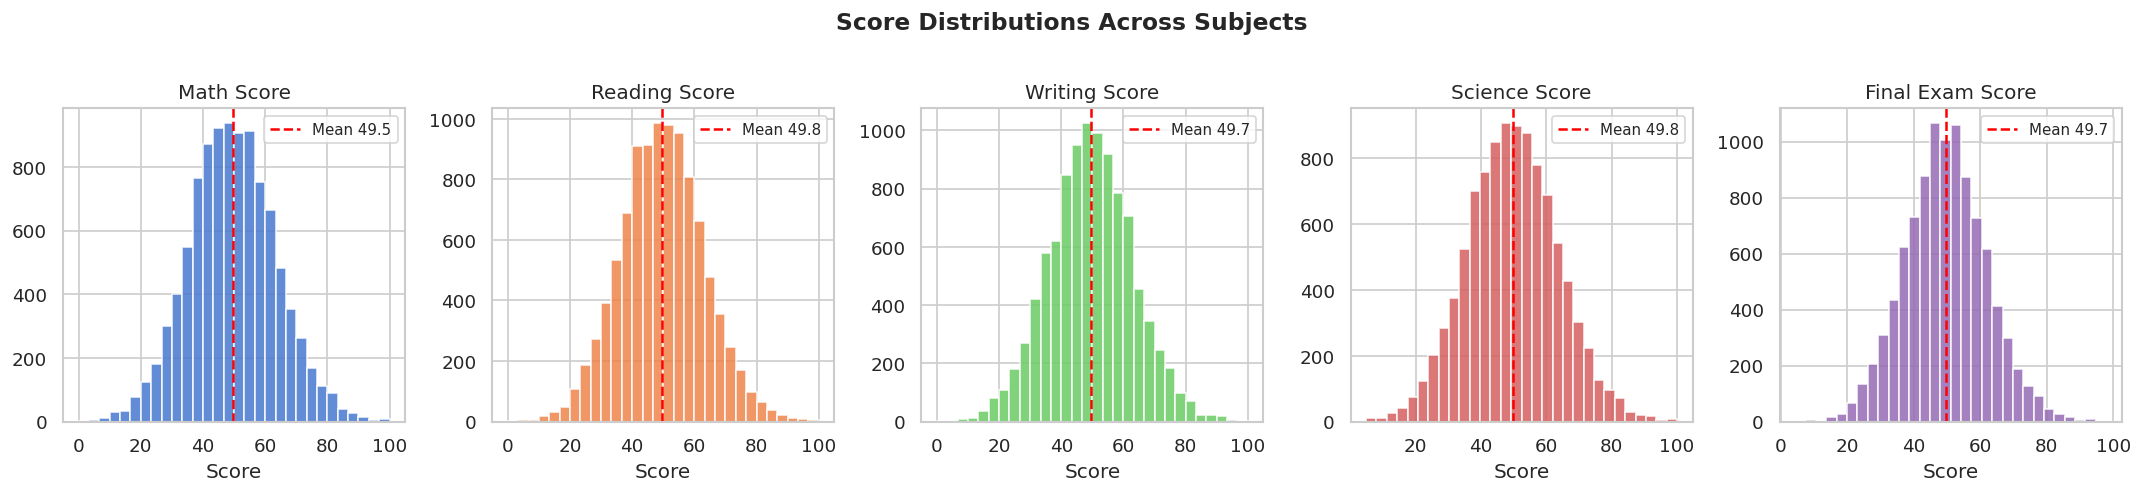

In [24]:
# Distribution of all numeric scores
score_cols = ['math_score','reading_score','writing_score','science_score','final_exam_score']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = sns.color_palette('muted', 5)

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean {df[col].mean():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.legend(fontsize=9)

fig.suptitle('Score Distributions Across Subjects', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Pass/Fail & Grade Distribution

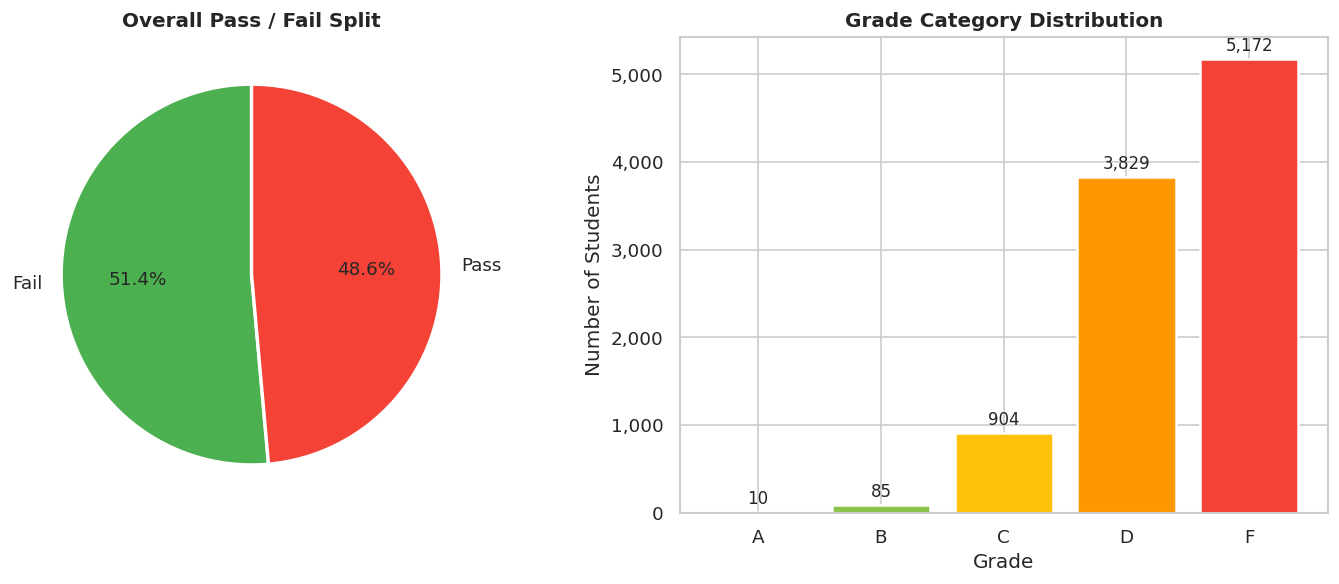


Pass rate: 48.6%


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pass/Fail pie
pf_counts = df['pass_fail'].value_counts()
ax1.pie(pf_counts, labels=pf_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50','#F44336'], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax1.set_title('Overall Pass / Fail Split', fontweight='bold')

# Grade category bar
grade_order = ['A','B','C','D','F']
grade_counts = df['grade_category'].value_counts().reindex(grade_order)
bars = ax2.bar(grade_counts.index, grade_counts.values,
               color=['#4CAF50','#8BC34A','#FFC107','#FF9800','#F44336'],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, grade_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{val:,}', ha='center', va='bottom', fontsize=10)
ax2.set_title('Grade Category Distribution', fontweight='bold')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Number of Students')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print('\nPass rate:', f"{pf_counts['Pass']/len(df)*100:.1f}%")

## 5. Study Hours vs. Performance

                  mean  median  count
study_hours_bin                      
0–1              35.96    35.7    485
1–2              41.15    41.2   1503
2–3              46.83    46.7   2982
3–4              52.18    52.1   2959
4–5              58.22    57.9   1586
5+               64.24    64.1    485


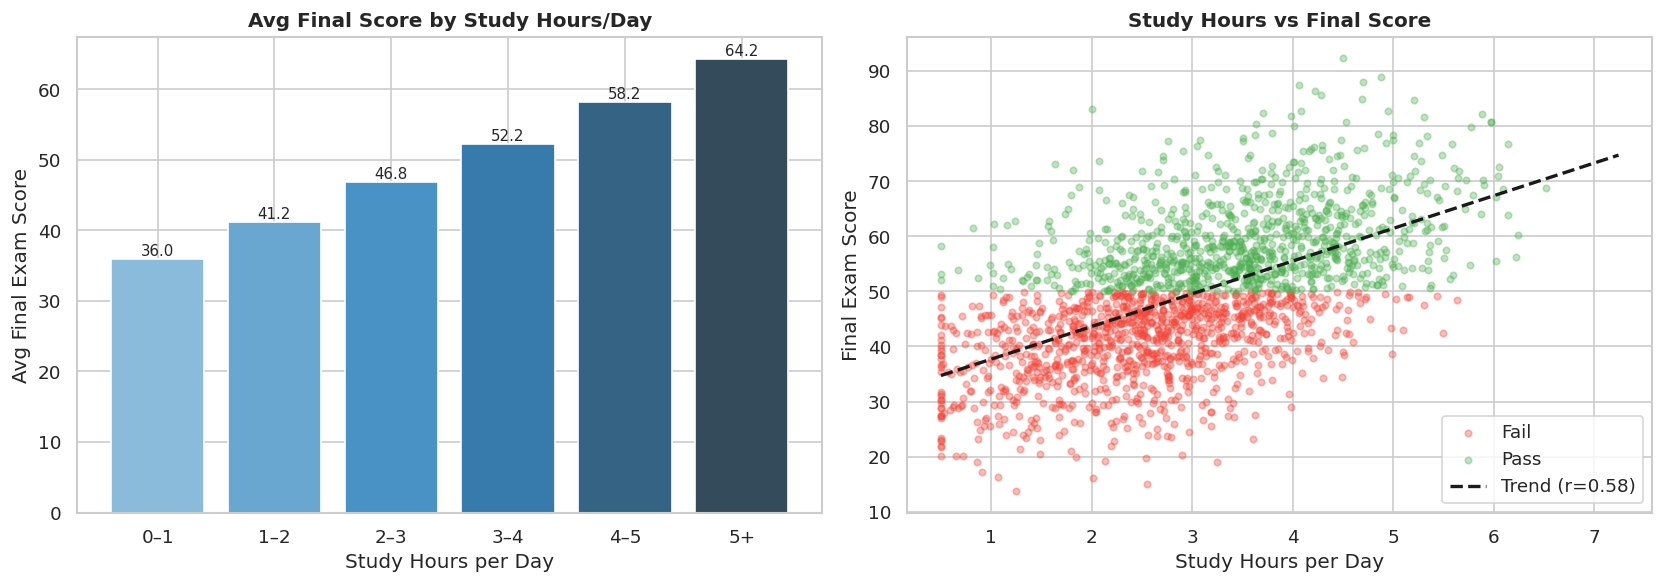


Pearson r (study_hours → final_score): 0.576  p-value: 0.0000


In [26]:
# Bin study hours into brackets
df['study_hours_bin'] = pd.cut(df['study_hours_per_day'],
                                bins=[0,1,2,3,4,5,10],
                                labels=['0–1','1–2','2–3','3–4','4–5','5+'])

study_perf = df.groupby('study_hours_bin', observed=True)['final_exam_score'].agg(['mean','median','count'])
print(study_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean score by study bracket
axes[0].bar(study_perf.index, study_perf['mean'],
            color=sns.color_palette('Blues_d', len(study_perf)), edgecolor='white')
axes[0].set_title('Avg Final Score by Study Hours/Day', fontweight='bold')
axes[0].set_xlabel('Study Hours per Day')
axes[0].set_ylabel('Avg Final Exam Score')
for i, (idx, row) in enumerate(study_perf.iterrows()):
    axes[0].text(i, row['mean']+0.5, f"{row['mean']:.1f}", ha='center', fontsize=9)

# Scatter: study hours vs final score, coloured by pass/fail
palette = {'Pass':'#4CAF50','Fail':'#F44336'}
sample = df.sample(2000, random_state=42)
for outcome, grp in sample.groupby('pass_fail'):
    axes[1].scatter(grp['study_hours_per_day'], grp['final_exam_score'],
                    alpha=0.35, s=15, label=outcome, color=palette[outcome])
# Regression line
m, b, r, p, _ = stats.linregress(df['study_hours_per_day'], df['final_exam_score'])
x_range = np.linspace(df['study_hours_per_day'].min(), df['study_hours_per_day'].max(), 100)
axes[1].plot(x_range, m*x_range+b, 'k--', linewidth=2, label=f'Trend (r={r:.2f})')
axes[1].set_title('Study Hours vs Final Score', fontweight='bold')
axes[1].set_xlabel('Study Hours per Day')
axes[1].set_ylabel('Final Exam Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nPearson r (study_hours → final_score): {r:.3f}  p-value: {p:.4f}')

## 6. Attendance & Sleep Impact

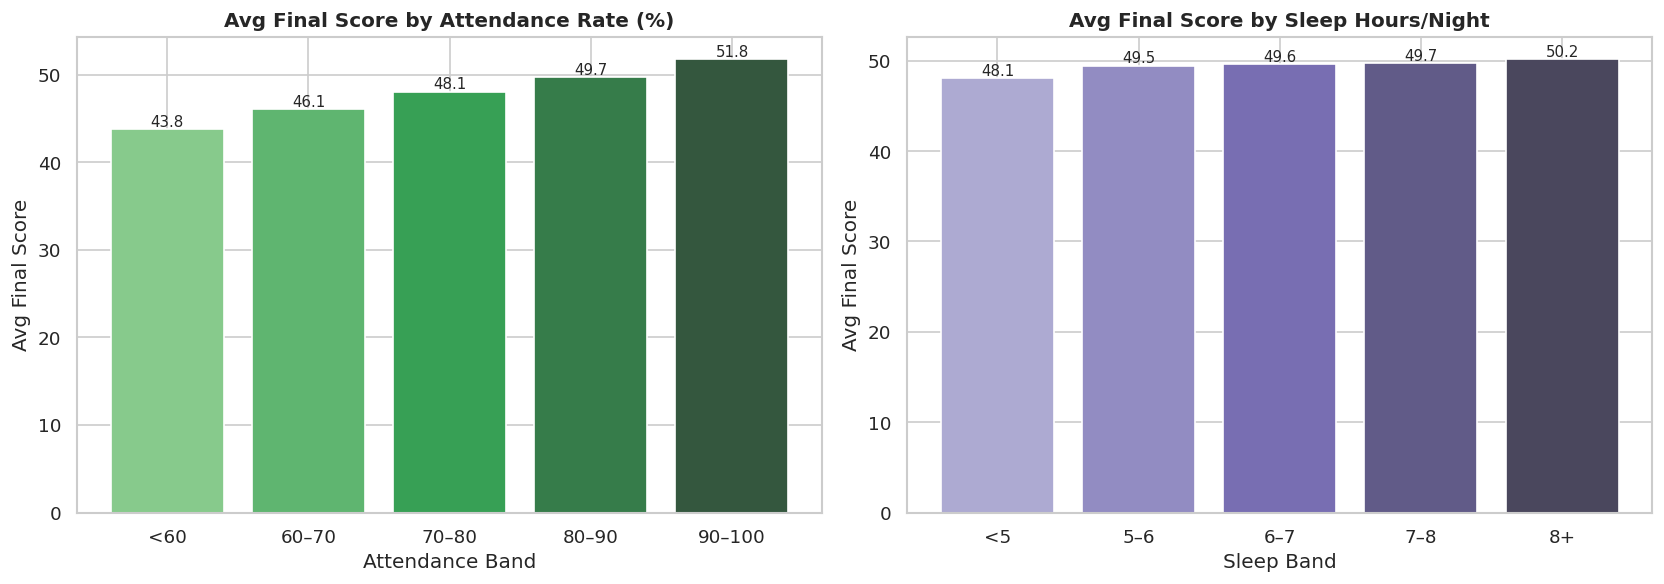

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attendance vs final score
df['attendance_bin'] = pd.cut(df['attendance_rate'], bins=[0,60,70,80,90,100],
                               labels=['<60','60–70','70–80','80–90','90–100'])
att_perf = df.groupby('attendance_bin', observed=True)['final_exam_score'].mean()
axes[0].bar(att_perf.index, att_perf.values,
            color=sns.color_palette('Greens_d', len(att_perf)), edgecolor='white')
axes[0].set_title('Avg Final Score by Attendance Rate (%)', fontweight='bold')
axes[0].set_xlabel('Attendance Band')
axes[0].set_ylabel('Avg Final Score')
for i, v in enumerate(att_perf.values):
    axes[0].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

# Sleep hours vs final score
df['sleep_bin'] = pd.cut(df['sleep_hours'], bins=[0,5,6,7,8,12],
                          labels=['<5','5–6','6–7','7–8','8+'])
sleep_perf = df.groupby('sleep_bin', observed=True)['final_exam_score'].mean()
axes[1].bar(sleep_perf.index, sleep_perf.values,
            color=sns.color_palette('Purples_d', len(sleep_perf)), edgecolor='white')
axes[1].set_title('Avg Final Score by Sleep Hours/Night', fontweight='bold')
axes[1].set_xlabel('Sleep Band')
axes[1].set_ylabel('Avg Final Score')
for i, v in enumerate(sleep_perf.values):
    axes[1].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
# Pass rate by attendance band
pass_by_att = df.groupby('attendance_bin', observed=True)['pass_fail'].apply(
    lambda x: (x=='Pass').mean()*100).round(1)
print('Pass rate (%) by attendance band:')
print(pass_by_att.to_string())

Pass rate (%) by attendance band:
attendance_bin
<60       22.4
60–70     36.4
70–80     43.8
80–90     47.8
90–100    56.3


## 7. Demographics: Gender & Parental Education

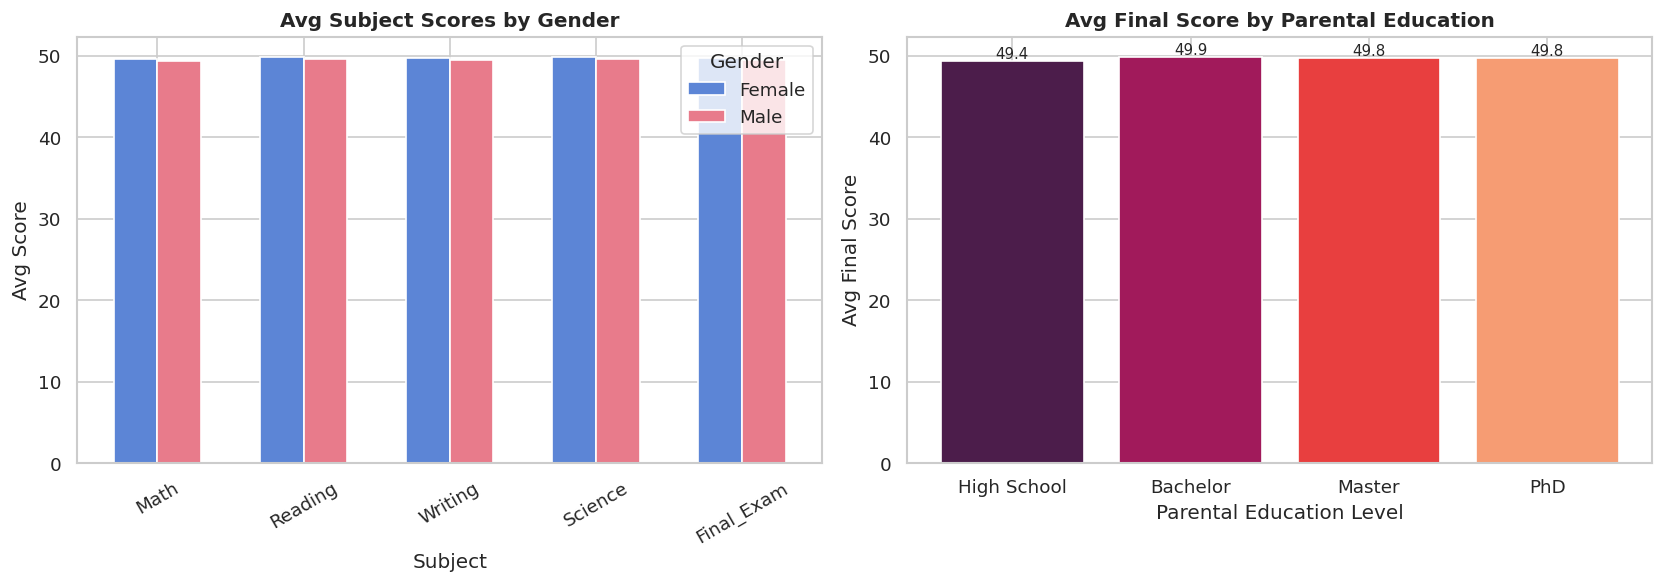

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender vs avg scores across subjects
gender_scores = df.groupby('gender')[score_cols].mean().T
gender_scores.index = [c.replace('_score','').title() for c in gender_scores.index]
gender_scores.plot(kind='bar', ax=axes[0],
                   color=['#5C85D6','#E87B8B'], edgecolor='white', width=0.6)
axes[0].set_title('Avg Subject Scores by Gender', fontweight='bold')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Avg Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Gender')

# Parental education vs final score
edu_order = ['High School','Bachelor','Master','PhD']
edu_perf = df.groupby('parental_education')['final_exam_score'].mean().reindex(edu_order)
axes[1].bar(edu_perf.index, edu_perf.values,
            color=sns.color_palette('rocket', len(edu_perf)), edgecolor='white')
axes[1].set_title('Avg Final Score by Parental Education', fontweight='bold')
axes[1].set_xlabel('Parental Education Level')
axes[1].set_ylabel('Avg Final Score')
for i, v in enumerate(edu_perf.values):
    axes[1].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# Gender pass rates
gender_pass = df.groupby('gender')['pass_fail'].apply(lambda x: (x=='Pass').mean()*100).round(1)
print('Pass rate (%) by gender:')
print(gender_pass.to_string())

# Parental education pass rates
edu_pass = df.groupby('parental_education')['pass_fail'].apply(lambda x: (x=='Pass').mean()*100).reindex(edu_order).round(1)
print('\nPass rate (%) by parental education:')
print(edu_pass.to_string())

Pass rate (%) by gender:
gender
Female    48.9
Male      48.3

Pass rate (%) by parental education:
parental_education
High School    47.3
Bachelor       49.8
Master         48.6
PhD            50.1


## 8. Socioeconomic & Environmental Factors

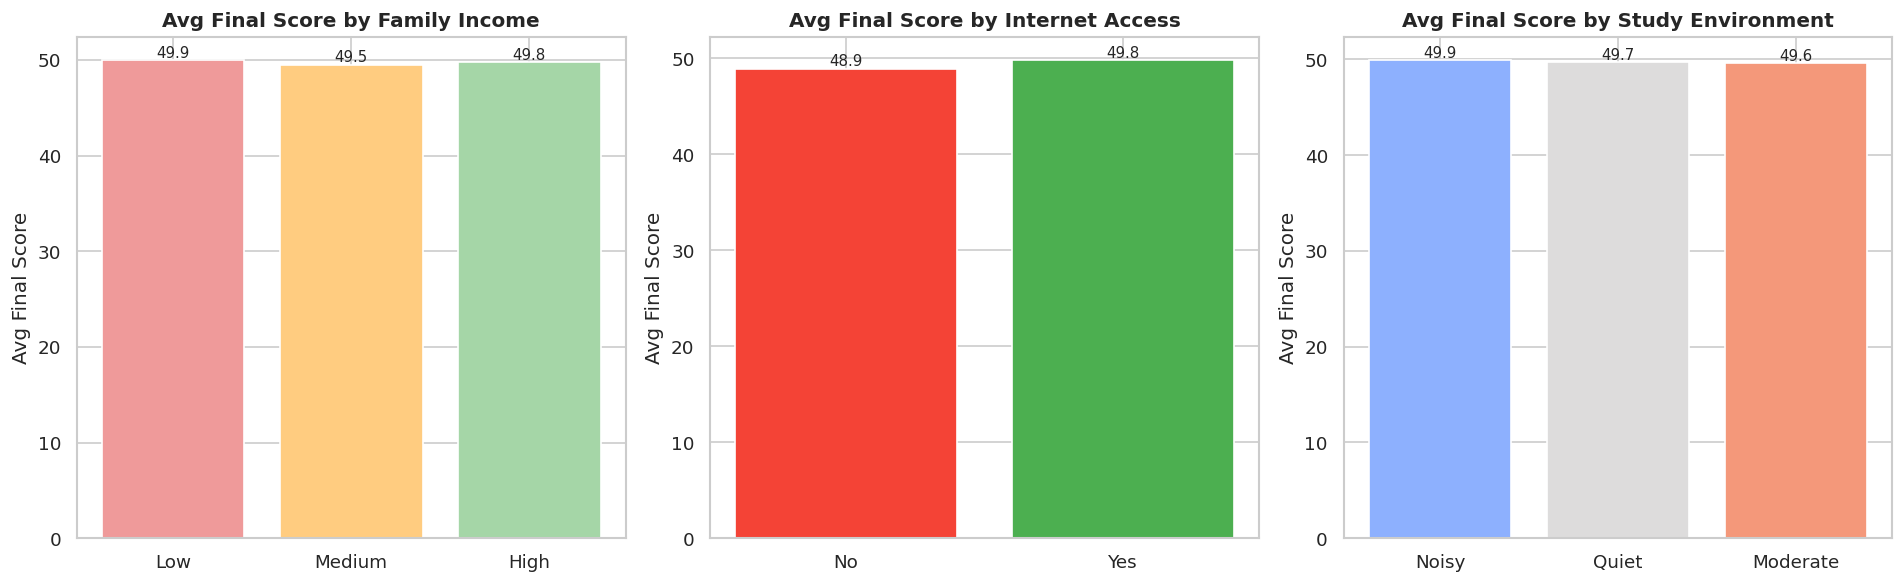

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Family income vs final score
income_order = ['Low','Medium','High']
income_perf = df.groupby('family_income')['final_exam_score'].mean().reindex(income_order)
axes[0].bar(income_order, income_perf.values,
            color=['#EF9A9A','#FFCC80','#A5D6A7'], edgecolor='white')
axes[0].set_title('Avg Final Score by Family Income', fontweight='bold')
axes[0].set_ylabel('Avg Final Score')
for i, v in enumerate(income_perf.values):
    axes[0].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

# Internet access
internet_perf = df.groupby('internet_access')['final_exam_score'].mean()
axes[1].bar(internet_perf.index, internet_perf.values,
            color=['#F44336','#4CAF50'], edgecolor='white')
axes[1].set_title('Avg Final Score by Internet Access', fontweight='bold')
axes[1].set_ylabel('Avg Final Score')
for i, v in enumerate(internet_perf.values):
    axes[1].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

# Study environment
env_perf = df.groupby('study_environment')['final_exam_score'].mean().sort_values(ascending=False)
axes[2].bar(env_perf.index, env_perf.values,
            color=sns.color_palette('coolwarm', 3), edgecolor='white')
axes[2].set_title('Avg Final Score by Study Environment', fontweight='bold')
axes[2].set_ylabel('Avg Final Score')
for i, v in enumerate(env_perf.values):
    axes[2].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
# Tutoring effect
tutor_perf = df.groupby('tutoring')['final_exam_score'].agg(['mean','count'])
tutor_pass = df.groupby('tutoring')['pass_fail'].apply(lambda x: (x=='Pass').mean()*100).round(1)
print('Tutoring impact:')
print(pd.concat([tutor_perf, tutor_pass.rename('pass_rate_%')], axis=1).round(2))

Tutoring impact:
           mean  count  pass_rate_%
tutoring                           
No        49.75   7004         48.7
Yes       49.53   2996         48.3


## 9. Correlation Heatmap

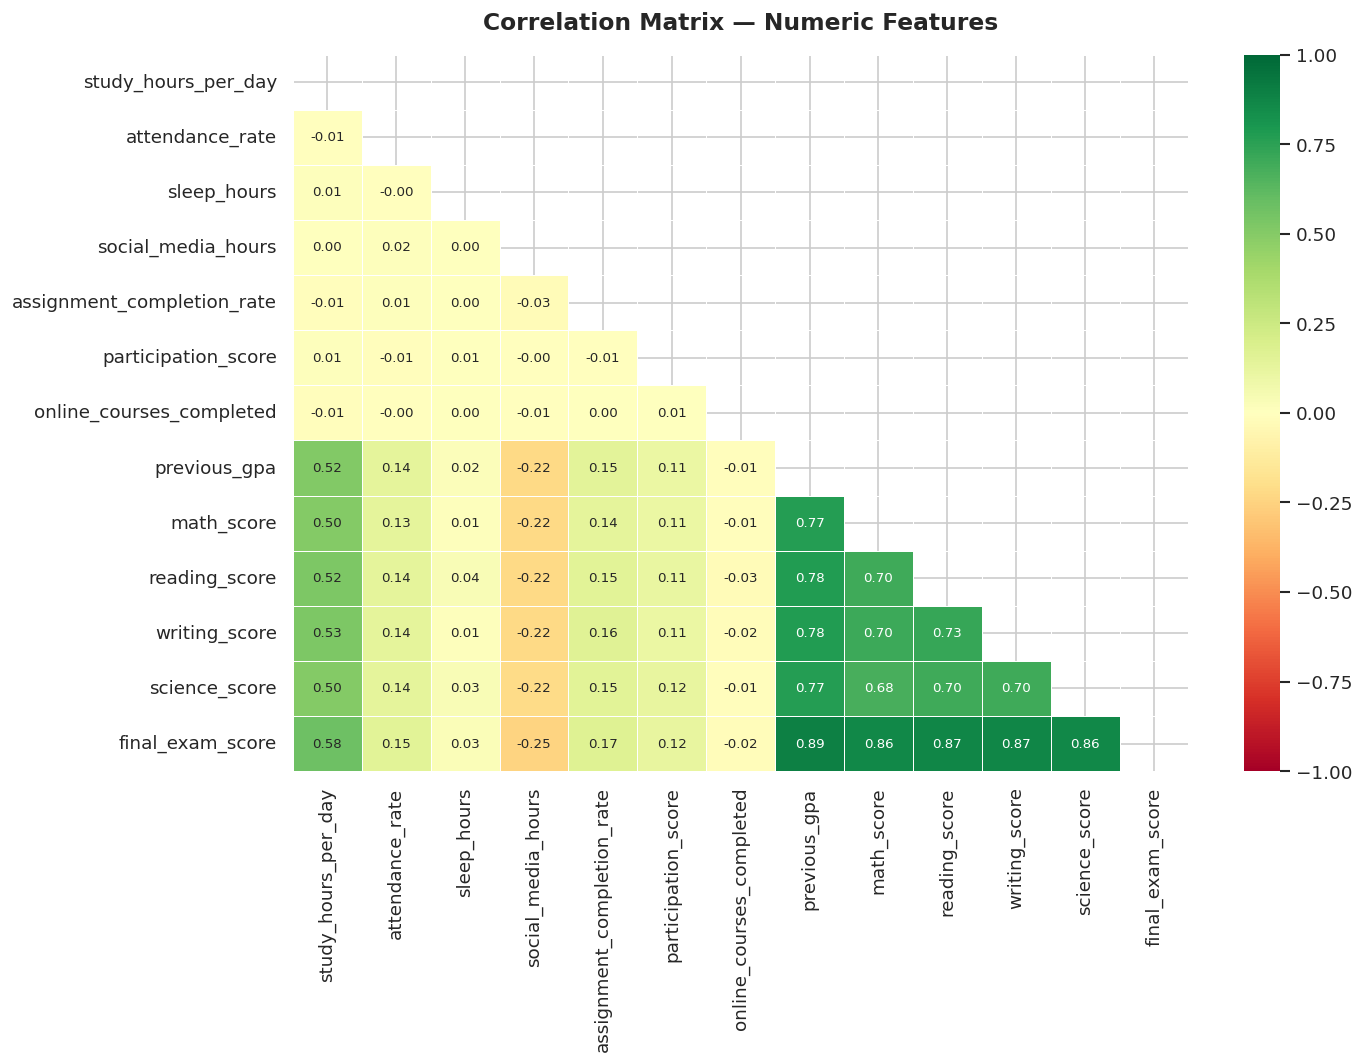


Top correlations with final_exam_score:
previous_gpa                  0.891
writing_score                 0.875
reading_score                 0.873
math_score                    0.864
science_score                 0.863
study_hours_per_day           0.576
assignment_completion_rate    0.171
attendance_rate               0.151
participation_score           0.124
sleep_hours                   0.028
online_courses_completed     -0.018
social_media_hours           -0.246
Name: final_exam_score, dtype: float64


In [33]:
numeric_cols = [
    'study_hours_per_day','attendance_rate','sleep_hours','social_media_hours',
    'assignment_completion_rate','participation_score','online_courses_completed',
    'previous_gpa','math_score','reading_score','writing_score','science_score',
    'final_exam_score'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size':8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with final_exam_score
print('\nTop correlations with final_exam_score:')
print(corr['final_exam_score'].drop('final_exam_score').sort_values(ascending=False).round(3))

## 10. Bonus — Interaction: Study Hours × Internet Access

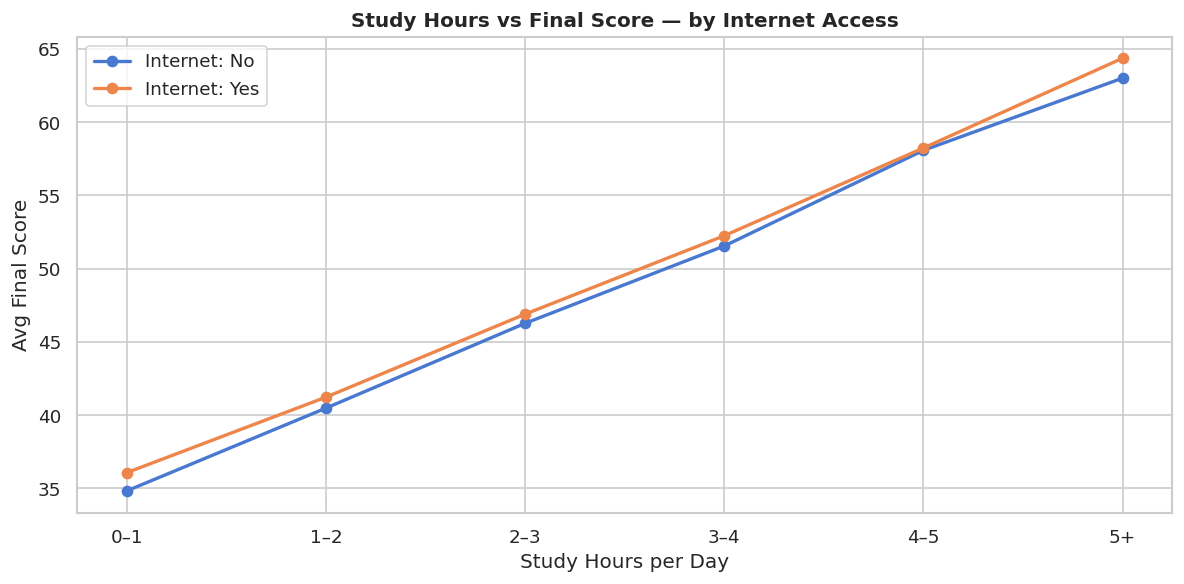

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

for internet, grp in df.groupby('internet_access'):
    grp_binned = grp.groupby('study_hours_bin', observed=True)['final_exam_score'].mean()
    ax.plot(grp_binned.index, grp_binned.values,
            marker='o', linewidth=2, label=f'Internet: {internet}')

ax.set_title('Study Hours vs Final Score — by Internet Access', fontweight='bold')
ax.set_xlabel('Study Hours per Day')
ax.set_ylabel('Avg Final Score')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Key Insights Summary

In [39]:
pass_rate   = (df['pass_fail']=='Pass').mean()*100
avg_final   = df['final_exam_score'].mean()
r_study, _  = stats.pearsonr(df['study_hours_per_day'], df['final_exam_score'])
r_attend, _ = stats.pearsonr(df['attendance_rate'],     df['final_exam_score'])
r_gpa, _    = stats.pearsonr(df['previous_gpa'],        df['final_exam_score'])
r_sleep, _  = stats.pearsonr(df['sleep_hours'],         df['final_exam_score'])
r_social, _ = stats.pearsonr(df['social_media_hours'],  df['final_exam_score'])


print(f'  Total students analysed : {len(df):,}')
print(f'  Overall pass rate        : {pass_rate:.1f}%')
print(f'  Mean final exam score    : {avg_final:.1f} / 100')
print()
print('  STRONGEST PREDICTORS OF FINAL SCORE:')
print(f'  • Previous GPA         r = {r_gpa:.3f}  ')
print(f'  • Study hours/day      r = {r_study:.3f}')
print(f'  • Attendance rate      r = {r_attend:.3f}')
print(f'  • Sleep hours          r = {r_sleep:.3f}  ')
print(f'  • Social media hours   r = {r_social:.3f}  ')
print()
print('  TOP BEHAVIOURAL INSIGHTS:')
top_study_pass = df[df['study_hours_per_day']>=4]['pass_fail'].value_counts(normalize=True)['Pass']*100
low_study_pass = df[df['study_hours_per_day']<2]['pass_fail'].value_counts(normalize=True)['Pass']*100
print(f'  • Students studying 4+ h/day pass at {top_study_pass:.1f}%')
print(f'    vs only {low_study_pass:.1f}% for <2 h/day')
high_att_pass = df[df['attendance_rate']>=90]['pass_fail'].value_counts(normalize=True)['Pass']*100
low_att_pass  = df[df['attendance_rate']<70]['pass_fail'].value_counts(normalize=True)['Pass']*100
print(f'  • 90%+ attendance → {high_att_pass:.1f}% pass rate')
print(f'    <70% attendance → {low_att_pass:.1f}% pass rate')
t_yes = df[df['tutoring']=='Yes']['final_exam_score'].mean()
t_no  = df[df['tutoring']=='No']['final_exam_score'].mean()
print(f'  • Tutored students avg {t_yes:.1f} vs {t_no:.1f} (no tutoring)')


  Total students analysed : 10,000
  Overall pass rate        : 48.6%
  Mean final exam score    : 49.7 / 100

  STRONGEST PREDICTORS OF FINAL SCORE:
  • Previous GPA         r = 0.891  
  • Study hours/day      r = 0.576
  • Attendance rate      r = 0.151
  • Sleep hours          r = 0.028  
  • Social media hours   r = -0.246  

  TOP BEHAVIOURAL INSIGHTS:
  • Students studying 4+ h/day pass at 83.0%
    vs only 14.7% for <2 h/day
  • 90%+ attendance → 56.3% pass rate
    <70% attendance → 34.7% pass rate
  • Tutored students avg 49.5 vs 49.7 (no tutoring)
